<a href="https://colab.research.google.com/github/Zeeshanmk66/Loan-Data-Analysis-and-Model-Training/blob/main/Loan_Risk_Assessment_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

loan_data = pd.read_csv('/test_Y3wMUE5_7gLdaTN.csv')

print(loan_data.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001015   Male     Yes          0      Graduate            No   
1  LP001022   Male     Yes          1      Graduate            No   
2  LP001031   Male     Yes          2      Graduate            No   
3  LP001035   Male     Yes          2      Graduate            No   
4  LP001051   Male      No          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5720                  0       110.0             360.0   
1             3076               1500       126.0             360.0   
2             5000               1800       208.0             360.0   
3             2340               2546       100.0             360.0   
4             3276                  0        78.0             360.0   

   Credit_History Property_Area  
0             1.0         Urban  
1             1.0         Urban  
2             1.0         Urban  
3             NaN     

File loaded successfully!

[NOTICE]: 'Loan_Status' column not found.
This file is a TEST set. You can use it for EDA, but you cannot train a model or calculate accuracy with it.
Please upload the 'train.csv' file to perform model training.


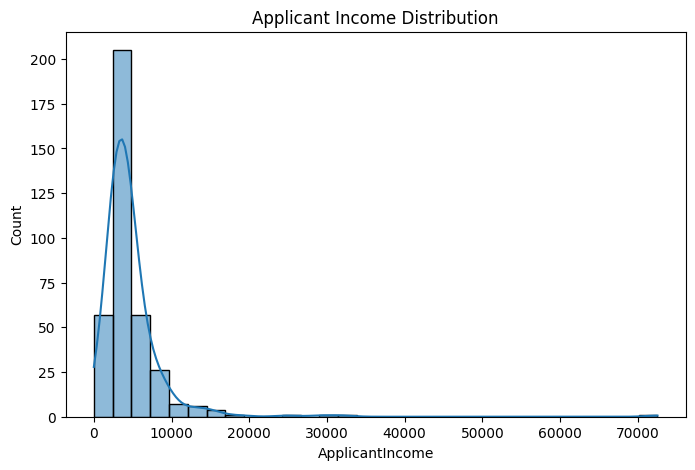

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Load the data using the absolute path you provided
try:
    loan_data = pd.read_csv('/test_Y3wMUE5_7gLdaTN.csv')
    print("File loaded successfully!")
except FileNotFoundError:
    print("File not found at /test_Y3wMUE5_7gLdaTN.csv. Please check the path.")

# 2. Handle Missing Values (Updated syntax to avoid FutureWarnings)
cols_to_fix_mode = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cols_to_fix_mode:
    loan_data[col] = loan_data[col].fillna(loan_data[col].mode()[0])

loan_data['LoanAmount'] = loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].mean())
loan_data['Loan_Amount_Term'] = loan_data['Loan_Amount_Term'].fillna(loan_data['Loan_Amount_Term'].mean())

# 3. Categorical Encoding
label_encoder = LabelEncoder()
categorical_columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

# Only add Loan_Status if it exists in the file
if 'Loan_Status' in loan_data.columns:
    categorical_columns.append('Loan_Status')

for col in categorical_columns:
    loan_data[col] = label_encoder.fit_transform(loan_data[col].astype(str))

# 4. Feature Selection & Modeling
# This part will only run if you have the 'Loan_Status' column
if 'Loan_Status' in loan_data.columns:
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score

    X = loan_data[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']]
    y = loan_data['Loan_Status']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    print(f"Model Accuracy: {accuracy_score(y_test, predictions)}")
else:
    print("\n[NOTICE]: 'Loan_Status' column not found.")
    print("This file is a TEST set. You can use it for EDA, but you cannot train a model or calculate accuracy with it.")
    print("Please upload the 'train.csv' file to perform model training.")

# 5. Sample Visualization (Works on any dataset)
plt.figure(figsize=(8,5))
sns.histplot(loan_data['ApplicantIncome'], bins=30, kde=True)
plt.title('Applicant Income Distribution')
plt.show()

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the TRAINING data
loan_data = pd.read_csv('/train_u6lujuX_CVtuZ9i.csv')

# Verify the target column exists
print("Dataset loaded. Column 'Loan_Status' found:", 'Loan_Status' in loan_data.columns)
loan_data.head()

Dataset loaded. Column 'Loan_Status' found: True


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the data
loan_data = pd.read_csv('/train_u6lujuX_CVtuZ9i.csv')
print("Data loaded successfully!")
loan_data.head()

Data loaded successfully!


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [11]:
# 1. Fill missing categorical values with Mode
cols_mode = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cols_mode:
    loan_data[col] = loan_data[col].fillna(loan_data[col].mode()[0])

# 2. Fill missing numerical values with Mean
loan_data['LoanAmount'] = loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].mean())
loan_data['Loan_Amount_Term'] = loan_data['Loan_Amount_Term'].fillna(loan_data['Loan_Amount_Term'].mean())

# 3. Label Encoding (Convert text to numbers)
le = LabelEncoder()
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in cat_cols:
    loan_data[col] = le.fit_transform(loan_data[col].astype(str))

# 4. Feature Scaling (Normalize numbers) [cite: 135]
scaler = StandardScaler()
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
loan_data[num_cols] = scaler.fit_transform(loan_data[num_cols])

print("Preprocessing complete!")

Preprocessing complete!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the TRAINING data [cite: 105, 106]
loan_data = pd.read_csv('/train_u6lujuX_CVtuZ9i.csv')

print("Step 1 Complete: Data loaded.")
loan_data.head()

Step 1 Complete: Data loaded.


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [14]:
# 1. Fill missing values [cite: 128-131]
cols_mode = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cols_mode:
    loan_data[col] = loan_data[col].fillna(loan_data[col].mode()[0])

loan_data['LoanAmount'] = loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].mean())
loan_data['Loan_Amount_Term'] = loan_data['Loan_Amount_Term'].fillna(loan_data['Loan_Amount_Term'].mean())

# 2. Convert text to numbers (Label Encoding) [cite: 132, 133]
le = LabelEncoder()
# We skip Loan_ID because it's just a name/ID
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in cat_cols:
    loan_data[col] = le.fit_transform(loan_data[col].astype(str))

# 3. Scaling (Standardizing) [cite: 134, 135]
scaler = StandardScaler()
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
loan_data[num_cols] = scaler.fit_transform(loan_data[num_cols])

print("Step 2 Complete: Data is clean and ready.")


Step 2 Complete: Data is clean and ready.


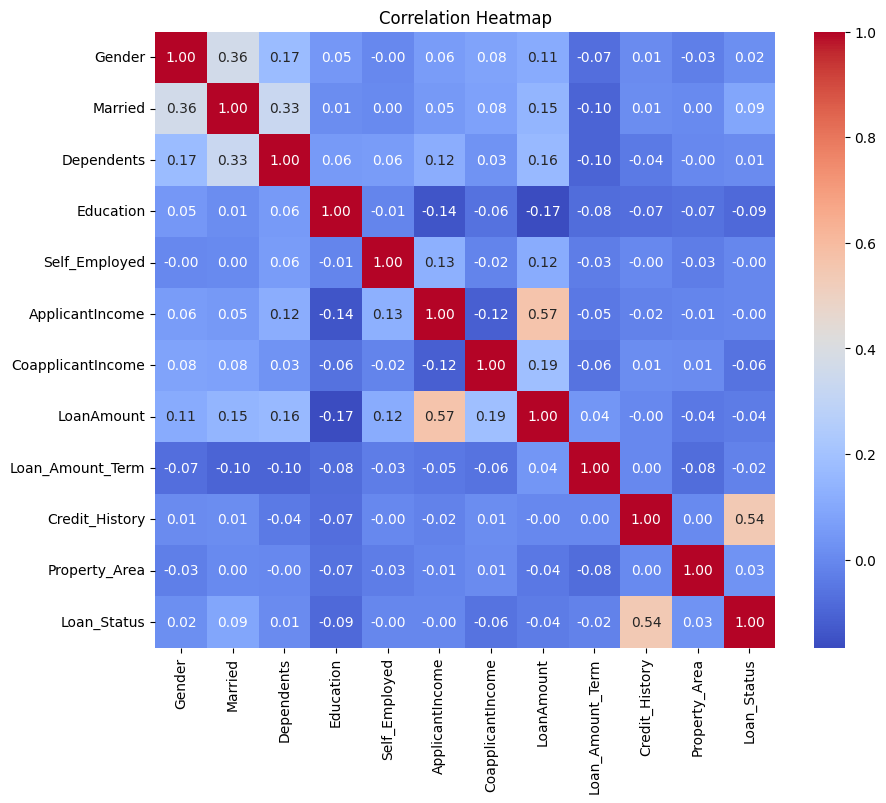

In [15]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
# 'numeric_only=True' tells the code to ignore text columns like Loan_ID
sns.heatmap(loan_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Insight: Look at the 'Loan_Status' row.
# You will see 'Credit_History' has the highest number (likely 0.54),
# meaning it's the most important factor[cite: 147, 173].

In [16]:
# 1. Prepare Features (X) and Target (y)
# We drop 'Loan_ID' here because it's not a feature for prediction
X = loan_data.drop(columns=['Loan_ID', 'Loan_Status'])
y = loan_data['Loan_Status']

# 2. Split into 80% Train and 20% Test [cite: 163-165]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define the Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 4. Print Results for your Report Table [cite: 168, 169]
print("Accuracy Results for your Report:")
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    print(f"{name}: {acc:.2%}")

Accuracy Results for your Report:
Logistic Regression: 78.86%
Decision Tree: 69.92%
Random Forest: 77.24%


In [17]:
# 1. Load the original TEST file (the one without status)
test_data = pd.read_csv('/test_Y3wMUE5_7gLdaTN.csv')

# 2. Apply the SAME cleaning as we did for train
test_data['Gender'] = test_data['Gender'].fillna(test_data['Gender'].mode()[0])
test_data['Married'] = test_data['Married'].fillna(test_data['Married'].mode()[0])
test_data['Dependents'] = test_data['Dependents'].fillna(test_data['Dependents'].mode()[0])
test_data['Self_Employed'] = test_data['Self_Employed'].fillna(test_data['Self_Employed'].mode()[0])
test_data['Credit_History'] = test_data['Credit_History'].fillna(test_data['Credit_History'].mode()[0])
test_data['LoanAmount'] = test_data['LoanAmount'].fillna(test_data['LoanAmount'].mean())
test_data['Loan_Amount_Term'] = test_data['Loan_Amount_Term'].fillna(test_data['Loan_Amount_Term'].mean())

# 3. Encoding (Only the features, since Status isn't here)
for col in ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']:
    test_data[col] = le.fit_transform(test_data[col].astype(str))

# 4. Use the Best Model (Random Forest) to Predict
X_new = test_data.drop(columns=['Loan_ID'])
# Make sure columns match X_train
X_new = X_new[X.columns]

# Get predictions: 1 = Low Risk (Approved), 0 = High Risk (Rejected)
test_predictions = models["Random Forest"].predict(X_new)

# 5. Save results to a CSV to show your teacher
output = pd.DataFrame({'Loan_ID': test_data['Loan_ID'], 'Risk_Prediction': test_predictions})
output['Risk_Prediction'] = output['Risk_Prediction'].map({1: 'Low Risk / Approved', 0: 'High Risk / Rejected'})
output.to_csv('Final_Risk_Assessment_Results.csv', index=False)

print("Final predictions saved to 'Final_Risk_Assessment_Results.csv'!")
output.head()

Final predictions saved to 'Final_Risk_Assessment_Results.csv'!


,Loan_ID,Risk_Prediction
0,LP001015,Low Risk / Approved
1,LP001022,High Risk / Rejected
2,LP001031,High Risk / Rejected
3,LP001035,High Risk / Rejected
4,LP001051,High Risk / Rejected
